# 01 — Data Pipeline & Window Construction

**FusionCore v1 — Phase Ph-v1.0 + Ph-v1.1**

This notebook ingests the FusionCore v0 NN-ready feature manifold, derives two
new physics-meaningful tokens ($\eta_c$ via Walsh & Fletcher 2004 and a Cox
proportional-hazards score via Cox 1972), assembles the augmented 89-feature
input matrix, builds sliding 30-cycle windows for the TCN branch, and packages
the result as PyTorch `DataLoader` objects ready for Ph-v1.2 (PiNet) and
Ph-v1.3 (Stage A training).

### Reading order at session start

1. `MICHELE-CLAUDE.md` — personal profile and Fan-Out / Fan-In / Synthesise workflow.
2. `v1/v1CLAUDE.md` — v1 project constitution; in particular §17 Roadmap Deviations Register.
3. Legacy root `CLAUDE.md` — frozen v0 invariants (palette, Iron Wall Protocol, sensor reference).
4. `reports/FusionCore_v1_Master_Roadmap.pdf` — authoritative technical specification.

### Phase scope

| Phase | Description | Acceptance gate |
|---|---|---|
| **Ph-v1.0** | Load v0 NN-ready parquet; verify partition disjointness; derive $\eta_c$ in physical space and z-normalise per regime; fit Cox PH on Internal Train; assemble augmented 89-feature matrix | 14 programmatic checks |
| **Ph-v1.1** | Sliding windows ($W=30$, stride 1) with forward-fill and attention mask; risk-band labels; class & regime weights; PyTorch `Dataset` + `DataLoader` | 19 programmatic checks |

### Roadmap deviations addressed

- **D-87** — 87-feature inheritance from v0 `_nn` parquet variants (s16 already excluded per v0 T2; s9_s14_ratio already P1/P99 clipped per v0 T3; CPR & E_thermal already Yeo–Johnson transformed per v0 T5).
- **D-CPR** — CPR formula is $s_7/s_3$ in z-space (v0 implementation), not the physical-space $s_7/s_5$ from the Master Roadmap.
- **D-YJ** — Yeo–Johnson transformer reused from v0 `phase4_yeo_johnson_transformer.pkl`; not refit.
- **A-1** — $\eta_c$ is a **new v1 artefact** — derived in physical space here.
- **A-2** — Cox PH $\beta$ is a **new v1 artefact** — fit on Internal Train here (v0 G12 was diagnostic only).

### Outputs (under `v1/outputs/`)

| File | Phase | Purpose |
|---|---|---|
| `phase_v1_0_eta_c_regime_zscore_params.pkl` | Ph-v1.0 | Per-regime $(\mu, \sigma)$ for the new $\eta_c$ token |
| `phase_v1_0_cox_ph.pkl` | Ph-v1.0 | Fitted `lifelines.CoxPHFitter` model |
| `X_train_v1.parquet`, `X_val_v1.parquet`, `X_test_v1.parquet` | Ph-v1.0 | Augmented 89-feature matrices |
| `v1_feature_names.pkl` | Ph-v1.0 | Alphabetised column manifest |
| `windows_train.pt`, `windows_val.pt`, `windows_test.pt` | Ph-v1.1 | Windowed tensors, masks, anchor metadata, weights |

### References

- Saxena, A. & Goebel, K. (2008). *Turbofan Engine Degradation Simulation Data Set*. NASA Ames.
- Heimes, F. O. (2008). Recurrent neural networks for RUL estimation. *PHM 2008*.
- Cox, D. R. (1972). Regression models and life-tables. *J. Royal Statistical Society B* 34(2), 187–220.
- Cox, D. R. (1975). Partial likelihood. *Biometrika* 62(2), 269–276.
- Walsh, P. P. & Fletcher, P. (2004). *Gas Turbine Performance* (2nd ed.). Blackwell.
- Davidson-Pilon, C. (2019). *lifelines: survival analysis in Python*. JOSS 4(40).


---

## Cell 1 — Dependencies

`lifelines` provides the Cox proportional-hazards fitter used in Part C.
`pyarrow` is required for parquet I/O. Both are installed silently.

In [1]:
%%capture
# ============================================================================
# Cell 1 — Dependency Installation
# ============================================================================

%pip install lifelines pyarrow

## Cell 2 — Imports

In [2]:
# ============================================================================
# Cell 2 — Imports
# ============================================================================

import sys, os, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt
import matplotlib as mpl

from lifelines import CoxPHFitter

warnings.filterwarnings("ignore")

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"pandas   : {pd.__version__}")
print(f"numpy    : {np.__version__}")

Python   : 3.13.13
PyTorch  : 2.11.0
pandas   : 2.3.3
numpy    : 2.4.4


## Cell 3 — Visualisation Setup (FusionCore palette)

The FusionCore colour palette is mandatory across every notebook.
See `MICHELE-CLAUDE.md` §3.2 (cross-reference to root v0 `CLAUDE.md` §4.2).

In [3]:
# ============================================================================
# Cell 3 — FusionCore Palette and Matplotlib Configuration
# ============================================================================

FC_DARK_BLUE  = "#0D1B2A"
FC_NAVY       = "#1B3A5C"
FC_ORANGE     = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"
FC_STEEL      = "#4A6274"
FC_CHARCOAL   = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"

FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]

plt.rcParams.update({
    "figure.figsize":   (14, 5),
    "figure.dpi":       110,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "font.family":      "serif",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   FC_CHARCOAL,
    "axes.labelcolor":  FC_CHARCOAL,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.prop_cycle":  mpl.cycler(color=FC_PALETTE),
    "xtick.color":      FC_CHARCOAL,
    "ytick.color":      FC_CHARCOAL,
    "legend.fontsize":  9,
    "legend.framealpha": 0.9,
    "grid.color":       FC_LIGHT_GREY,
    "grid.alpha":       0.6,
    "grid.linestyle":   ":",
})

print("Visualisation configured (FusionCore palette).")

Visualisation configured (FusionCore palette).


## Cell 4 — Project Constants and Paths

Paths point to the local v0 outputs (`/Users/.../v0/outputs/`) per decision D1.
The `v1/outputs/` directory is created on first run. Apple Silicon MPS is
preferred for downstream training notebooks; this Phase 0/1 notebook is purely
data preparation and runs on CPU.

In [4]:
# ============================================================================
# Cell 4 — Project Constants, Paths, Seeds, and Hyperparameters
# ============================================================================

# Project paths (Apple Silicon MPS, local).
PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V0_OUT       = PROJECT_ROOT / "v0" / "outputs"
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"
DATASETS     = PROJECT_ROOT / "Datasets" / "CMAPSS"
V1_OUT.mkdir(parents=True, exist_ok=True)

# Reproducibility (FusionCore canonical seed).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Compute device (used in Ph-v1.3 training; not in Ph-v1.0/1).
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# v1 hyperparameters (frozen; see v1CLAUDE.md §6).
W           = 30           # window length in cycles
STRIDE      = 1
RUL_CAP     = 125
GAMMA_AIR   = 1.4          # specific-heat ratio for air (Walsh & Fletcher 2004)
HEALTHY_TH  = 80           # RUL >= 80
WARNING_TH  = 30           # 30 <= RUL < 80; below is Critical
BATCH_SIZE  = 64

# Composite key for engine-level operations.
UNIT_KEY = ["subset_origin", "unit_id"]

print(f"Device         : {DEVICE}")
print(f"V0 outputs at  : {V0_OUT}")
print(f"V1 outputs at  : {V1_OUT}")
print(f"Datasets at    : {DATASETS}")
print(f"Window length  : W = {W} cycles, stride = {STRIDE}")
print(f"Risk bands     : Healthy >= {HEALTHY_TH}, Warning >= {WARNING_TH}, Critical < {WARNING_TH}")

Device         : mps
V0 outputs at  : /Users/michelemaestrini/Desktop/PiNet/FusionCore/v0/outputs
V1 outputs at  : /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs
Datasets at    : /Users/michelemaestrini/Desktop/PiNet/FusionCore/Datasets/CMAPSS
Window length  : W = 30 cycles, stride = 1
Risk bands     : Healthy >= 80, Warning >= 30, Critical < 30


---

## Part A — Load v0 Frozen Artefacts (Ph-v1.0)

Per `v1CLAUDE.md` §2, v1 inherits the v0 NN-ready manifold (`X_{train,val,test}_nn.parquet`,
87 features each — T2 s16 exclusion, T3 s9_s14_ratio P1/P99 clip, and T5 Yeo–Johnson on
CPR & E_thermal already baked in). All v0 artefacts are read-only here.

In [5]:
# ============================================================================
# Cell 5 — Load v0 NN-Ready Feature Matrices and Targets
# ============================================================================

X_train = pd.read_parquet(V0_OUT / "X_train_nn.parquet")
X_val   = pd.read_parquet(V0_OUT / "X_val_nn.parquet")
X_test  = pd.read_parquet(V0_OUT / "X_test_nn.parquet")

y_train = pd.read_parquet(V0_OUT / "y_train.parquet")
y_val   = pd.read_parquet(V0_OUT / "y_val.parquet")
y_test  = pd.read_parquet(V0_OUT / "y_test.parquet")

m_train = pd.read_parquet(V0_OUT / "meta_train.parquet")
m_val   = pd.read_parquet(V0_OUT / "meta_val.parquet")
m_test  = pd.read_parquet(V0_OUT / "meta_test.parquet")

print(f"X_train_nn shape : {X_train.shape}")
print(f"X_val_nn   shape : {X_val.shape}")
print(f"X_test_nn  shape : {X_test.shape}")
print(f"y_train    shape : {y_train.shape}   columns: {list(y_train.columns)}")
print(f"y_test     shape : {y_test.shape}    columns: {list(y_test.columns)}")
print(f"meta_train cols  : {list(m_train.columns)}")

X_train_nn shape : (129331, 87)
X_val_nn   shape : (31028, 87)
X_test_nn  shape : (104897, 87)
y_train    shape : (129331, 1)   columns: ['RUL']
y_test     shape : (707, 3)    columns: ['RUL', 'unit_id', 'subset_origin']
meta_train cols  : ['subset_origin', 'unit_id', 'cycle']


In [6]:
# ============================================================================
# Cell 6 — Load v0 Frozen Statistical Artefacts
# ============================================================================

nn_feature_names  = joblib.load(V0_OUT / "nn_feature_names.pkl")
regime_z_params   = joblib.load(V0_OUT / "regime_dictionary" / "regime_zscore_params.pkl")
regime_w_train_v0 = joblib.load(V0_OUT / "phase4a_regime_weights_train.pkl")
regime_w_val_v0   = joblib.load(V0_OUT / "phase4a_regime_weights_val.pkl")

# regime_w_train_v0 is a per-row ndarray (length = len(X_train_nn)) — not a per-regime dict.
# It encodes the inverse-frequency regime weight already evaluated per row by v0 Phase 4a.

print(f"NN feature count                : {len(nn_feature_names)}")
print(f"Regime z-params keys (subsets)  : {list(regime_z_params.keys())}")
print(f"Regime weights train  (per-row) : shape={regime_w_train_v0.shape}, "
      f"unique values={np.unique(regime_w_train_v0).round(4).tolist()}")
print(f"Regime weights val    (per-row) : shape={regime_w_val_v0.shape}")

NN feature count                : 87
Regime z-params keys (subsets)  : ['FD001', 'FD002', 'FD003', 'FD004']
Regime weights train  (per-row) : shape=(129331,), unique values=[0.3050000071525574, 0.882099986076355, 1.1979999542236328, 1.2008999586105347, 1.2044999599456787, 1.2094999551773071]
Regime weights val    (per-row) : shape=(31028,)


In [7]:
# ============================================================================
# Cell 7 — Composite-Key Disjointness Verification (Iron Wall Protocol)
# ============================================================================
# v1CLAUDE.md §10 LR-01 — engine-level disjointness verification.
#
# Important caveat about NASA C-MAPSS partition mechanics:
#
#   * train_FD00x.txt and test_FD00x.txt are SEPARATE files.  Within each
#     file, NASA reuses unit_id = 1..N as an independent counter — so the
#     row keyed (FD001, unit_id=1) in train_FD001.txt and the row keyed
#     (FD001, unit_id=1) in test_FD001.txt are DIFFERENT physical engines.
#     The partition between train and test is enforced by the file boundary,
#     not by the composite key.
#
#   * v0 GroupShuffleSplit operates within the train_FD00x.txt files only,
#     producing the (Internal Train, Internal Val) split at the engine level.
#     For this split, the composite key (subset_origin, unit_id) IS sufficient
#     to enforce engine-level disjointness, and that is the assertion below.
#
#   * Train ∩ Test and Val ∩ Test cannot be verified via composite key for
#     the reason above; their disjointness is guaranteed by construction
#     (separate NASA files).  We document this explicitly rather than
#     asserting a meaningless check.

def composite_key_set(meta: pd.DataFrame) -> set:
    return set(zip(meta["subset_origin"].astype(str),
                   meta["unit_id"].astype(int)))

train_keys = composite_key_set(m_train)
val_keys   = composite_key_set(m_val)
test_keys  = composite_key_set(m_test)

# Internal Train ∩ Internal Val — composite-key disjointness check.
# This is the real GroupShuffleSplit verification.
assert len(train_keys & val_keys) == 0, "Train/Val engine overlap detected — GroupShuffleSplit broken"

# Train ∩ Test and Val ∩ Test — NASA file-boundary separation; report only.
overlap_train_test = len(train_keys & test_keys)
overlap_val_test   = len(val_keys & test_keys)

print(f"Train engines : {len(train_keys):>4d}    rows: {len(m_train):>7,d}")
print(f"Val   engines : {len(val_keys):>4d}    rows: {len(m_val):>7,d}")
print(f"Test  engines : {len(test_keys):>4d}    rows: {len(m_test):>7,d}")
print()
print(f"Internal Train ∩ Internal Val : {len(train_keys & val_keys)}  (asserted == 0)")
print(f"Train keys ∩ Test keys (NASA) : {overlap_train_test}  (file-boundary separated; expected non-zero by NASA convention)")
print(f"Val   keys ∩ Test keys (NASA) : {overlap_val_test}  (file-boundary separated; expected non-zero by NASA convention)")
print()
print("Disjointness : PASS  (Internal Train ↔ Internal Val verified; Train ↔ Test by file boundary)")

Train engines :  567    rows: 129,331
Val   engines :  142    rows:  31,028
Test  engines :  707    rows: 104,897

Internal Train ∩ Internal Val : 0  (asserted == 0)
Train keys ∩ Test keys (NASA) : 565  (file-boundary separated; expected non-zero by NASA convention)
Val   keys ∩ Test keys (NASA) : 142  (file-boundary separated; expected non-zero by NASA convention)

Disjointness : PASS  (Internal Train ↔ Internal Val verified; Train ↔ Test by file boundary)


---

## Part B — Compute $\eta_c$ (overall compressor isentropic efficiency)

Per `v1CLAUDE.md` §17.2 A-1, $\eta_c$ is derived in **physical space** from the raw
`train_FD00x.txt` and `test_FD00x.txt` files using the Walsh & Fletcher 2004 formulation:

$$\eta_c = \frac{T_2 \left(P_{30}/P_2\right)^{(\gamma-1)/\gamma} - T_2}{T_{30} - T_2}$$

with $\gamma = 1.4$ (air specific-heat ratio) and the C-MAPSS column mapping
`s1`$\to T_2$, `s3`$\to T_{30}$, `s5`$\to P_2$, `s7`$\to P_{30}$.

The result is then z-score-normalised within each of the six operational regimes
using parameters fit on **Internal Train rows only** (Iron Wall — LR-02).
Per-regime parameters extend the v0 frozen regime dictionary; the new dict is
serialised as `phase_v1_0_eta_c_regime_zscore_params.pkl`.

In [8]:
# ============================================================================
# Cell 8 — C-MAPSS Raw-File Loader
# ============================================================================

CMAPSS_COLUMNS = [
    "unit_id", "cycle",
    "op1", "op2", "op3",
    "s1","s2","s3","s4","s5","s6","s7","s8","s9","s10",
    "s11","s12","s13","s14","s15","s16","s17","s18","s19","s20","s21",
]

def load_raw_cmapss(filepath: Path, subset: str) -> pd.DataFrame:
    """Load one C-MAPSS .txt file and tag with subset_origin."""
    df = pd.read_csv(filepath, sep=r"\s+", header=None, names=CMAPSS_COLUMNS)
    df.dropna(axis=1, how="all", inplace=True)
    df["subset_origin"] = subset
    return df

raw_train = pd.concat([
    load_raw_cmapss(DATASETS / f"train_{s}.txt", s)
    for s in ["FD001","FD002","FD003","FD004"]
], ignore_index=True)

raw_test = pd.concat([
    load_raw_cmapss(DATASETS / f"test_{s}.txt", s)
    for s in ["FD001","FD002","FD003","FD004"]
], ignore_index=True)

print(f"raw_train rows : {len(raw_train):>7,d}   per subset: {raw_train.subset_origin.value_counts().to_dict()}")
print(f"raw_test  rows : {len(raw_test):>7,d}   per subset: {raw_test.subset_origin.value_counts().to_dict()}")

raw_train rows : 160,359   per subset: {'FD004': 61249, 'FD002': 53759, 'FD003': 24720, 'FD001': 20631}
raw_test  rows : 104,897   per subset: {'FD004': 41214, 'FD002': 33991, 'FD003': 16596, 'FD001': 13096}


In [9]:
# ============================================================================
# Cell 9 — Compute eta_c (Physical Space, Walsh & Fletcher 2004)
# ============================================================================

def compute_eta_c_physical(df_raw: pd.DataFrame, gamma: float = GAMMA_AIR) -> pd.Series:
    """Overall compressor isentropic efficiency.
    eta_c = (T2 * (P30/P2)^((gamma-1)/gamma) - T2) / (T30 - T2)
    """
    T2  = df_raw["s1"].to_numpy(dtype=np.float64)
    T30 = df_raw["s3"].to_numpy(dtype=np.float64)
    P2  = df_raw["s5"].to_numpy(dtype=np.float64)
    P30 = df_raw["s7"].to_numpy(dtype=np.float64)

    exponent     = (gamma - 1.0) / gamma
    T30_ideal    = T2 * np.power(P30 / P2, exponent)
    numerator    = T30_ideal - T2
    denominator  = T30 - T2
    eta = np.where(np.abs(denominator) > 1e-6, numerator / denominator, np.nan)
    return pd.Series(eta, index=df_raw.index, name="eta_c_phys")

raw_train["eta_c_phys"] = compute_eta_c_physical(raw_train)
raw_test["eta_c_phys"]  = compute_eta_c_physical(raw_test)

print(f"eta_c_phys NaN — train: {int(raw_train['eta_c_phys'].isna().sum())}, "
      f"test: {int(raw_test['eta_c_phys'].isna().sum())}")
print()
print("eta_c_phys descriptive statistics by subset (train pool):")
print(raw_train.groupby("subset_origin")["eta_c_phys"].describe().round(4).T)

eta_c_phys NaN — train: 0, test: 0

eta_c_phys descriptive statistics by subset (train pool):
subset_origin       FD001       FD002       FD003       FD004
count          20631.0000  53759.0000  24720.0000  61249.0000
mean               0.8827      0.8733      0.8860      0.8761
std                0.0055      0.0082      0.0055      0.0083
min                0.8600      0.8438      0.8615      0.8428
25%                0.8792      0.8675      0.8828      0.8703
50%                0.8831      0.8731      0.8866      0.8760
75%                0.8865      0.8794      0.8898      0.8823
max                0.9000      0.9021      0.9027      0.9025


In [10]:
# ============================================================================
# Cell 10 — Merge eta_c onto v0 Partition Matrices via Composite Key + Cycle
# ============================================================================
# Train and Val engines both live in train_FD00x.txt (the GroupShuffleSplit
# at v0 Phase 2 partitioned them by engine, not by subset).  Test engines
# live in test_FD00x.txt.

def merge_eta_c(meta: pd.DataFrame, raw_pool: pd.DataFrame) -> np.ndarray:
    merged = meta.merge(
        raw_pool[["subset_origin","unit_id","cycle","eta_c_phys"]],
        on=["subset_origin","unit_id","cycle"], how="left",
    )
    return merged["eta_c_phys"].to_numpy(dtype=np.float64)

eta_train_phys = merge_eta_c(m_train, raw_train)
eta_val_phys   = merge_eta_c(m_val,   raw_train)
eta_test_phys  = merge_eta_c(m_test,  raw_test)

assert not np.isnan(eta_train_phys).any(), "NaN in eta_c_phys (train) after merge"
assert not np.isnan(eta_val_phys).any(),   "NaN in eta_c_phys (val) after merge"
assert not np.isnan(eta_test_phys).any(),  "NaN in eta_c_phys (test) after merge"

print(f"eta_c_phys train  μ = {eta_train_phys.mean():.4f}    σ = {eta_train_phys.std():.4f}")
print(f"eta_c_phys val    μ = {eta_val_phys.mean():.4f}    σ = {eta_val_phys.std():.4f}")
print(f"eta_c_phys test   μ = {eta_test_phys.mean():.4f}    σ = {eta_test_phys.std():.4f}")

eta_c_phys train  μ = 0.8776    σ = 0.0089
eta_c_phys val    μ = 0.8773    σ = 0.0089
eta_c_phys test   μ = 0.8793    σ = 0.0083


In [11]:
# ============================================================================
# Cell 11 — Extract regime_id Per Row from One-Hot Encoding
# ============================================================================
# v0 Phase 3 stored regime as 6 one-hot columns (regime_0..regime_5).  Recover
# the integer regime id by argmax for use in per-regime z-normalisation.

def regime_id_per_row(X: pd.DataFrame) -> np.ndarray:
    cols = [f"regime_{i}" for i in range(6)]
    return np.argmax(X[cols].to_numpy(), axis=1).astype(int)

reg_train = regime_id_per_row(X_train)
reg_val   = regime_id_per_row(X_val)
reg_test  = regime_id_per_row(X_test)

print(f"Regime distribution (train): {np.bincount(reg_train, minlength=6).tolist()}")
print(f"Regime distribution (val)  : {np.bincount(reg_val,   minlength=6).tolist()}")
print(f"Regime distribution (test) : {np.bincount(reg_test,  minlength=6).tolist()}")

Regime distribution (train): [54805, 13954, 13821, 13879, 13920, 18952]
Regime distribution (val)  : [13166, 3328, 3320, 3308, 3426, 4480]
Regime distribution (test) : [44407, 11202, 11149, 11361, 11248, 15530]


In [12]:
# ============================================================================
# Cell 12 — Fit eta_c Per-Regime Z-Score on Internal Train (Iron Wall)
# ============================================================================

def fit_eta_c_regime_zscore(eta_phys: np.ndarray, regime: np.ndarray, n_regimes: int = 6) -> dict:
    params = {}
    for r in range(n_regimes):
        mask = (regime == r)
        if mask.sum() == 0:
            params[r] = {"mu": 0.0, "sigma": 1.0, "n": 0}
            continue
        mu  = float(np.mean(eta_phys[mask]))
        sig = float(np.std(eta_phys[mask], ddof=0))
        params[r] = {"mu": mu, "sigma": max(sig, 1e-8), "n": int(mask.sum())}
    return params

def apply_eta_c_regime_zscore(eta_phys: np.ndarray, regime: np.ndarray, params: dict) -> np.ndarray:
    out = np.empty_like(eta_phys, dtype=np.float32)
    for r, p in params.items():
        mask = (regime == r)
        if mask.any():
            out[mask] = (eta_phys[mask] - p["mu"]) / p["sigma"]
    return out

eta_zparams = fit_eta_c_regime_zscore(eta_train_phys, reg_train)
eta_train   = apply_eta_c_regime_zscore(eta_train_phys, reg_train, eta_zparams)
eta_val     = apply_eta_c_regime_zscore(eta_val_phys,   reg_val,   eta_zparams)
eta_test    = apply_eta_c_regime_zscore(eta_test_phys,  reg_test,  eta_zparams)

print("Per-regime fit (Internal Train):")
for r, p in eta_zparams.items():
    print(f"  Regime {r}: μ = {p['mu']:>9.4f}    σ = {p['sigma']:>9.4f}    n = {p['n']:>7,d}")
print()
print(f"eta_c (z-space) train  μ = {eta_train.mean():.6f}    σ = {eta_train.std():.6f}")
print(f"eta_c (z-space) val    μ = {eta_val.mean():.6f}    σ = {eta_val.std():.6f}")
print(f"eta_c (z-space) test   μ = {eta_test.mean():.6f}    σ = {eta_test.std():.6f}")

Per-regime fit (Internal Train):
  Regime 0: μ =    0.8793    σ =    0.0095    n =  54,805
  Regime 1: μ =    0.8843    σ =    0.0056    n =  13,954
  Regime 2: μ =    0.8718    σ =    0.0065    n =  13,821
  Regime 3: μ =    0.8793    σ =    0.0060    n =  13,879
  Regime 4: μ =    0.8793    σ =    0.0055    n =  13,920
  Regime 5: μ =    0.8693    σ =    0.0059    n =  18,952

eta_c (z-space) train  μ = 0.000000    σ = 1.000000
eta_c (z-space) val    μ = -0.047050    σ = 0.997770
eta_c (z-space) test   μ = 0.251558    σ = 0.894185


In [13]:
# ============================================================================
# Cell 13 — Persist eta_c Regime Z-Score Parameters
# ============================================================================

joblib.dump(eta_zparams, V1_OUT / "phase_v1_0_eta_c_regime_zscore_params.pkl")
print(f"Saved {V1_OUT / 'phase_v1_0_eta_c_regime_zscore_params.pkl'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs/phase_v1_0_eta_c_regime_zscore_params.pkl


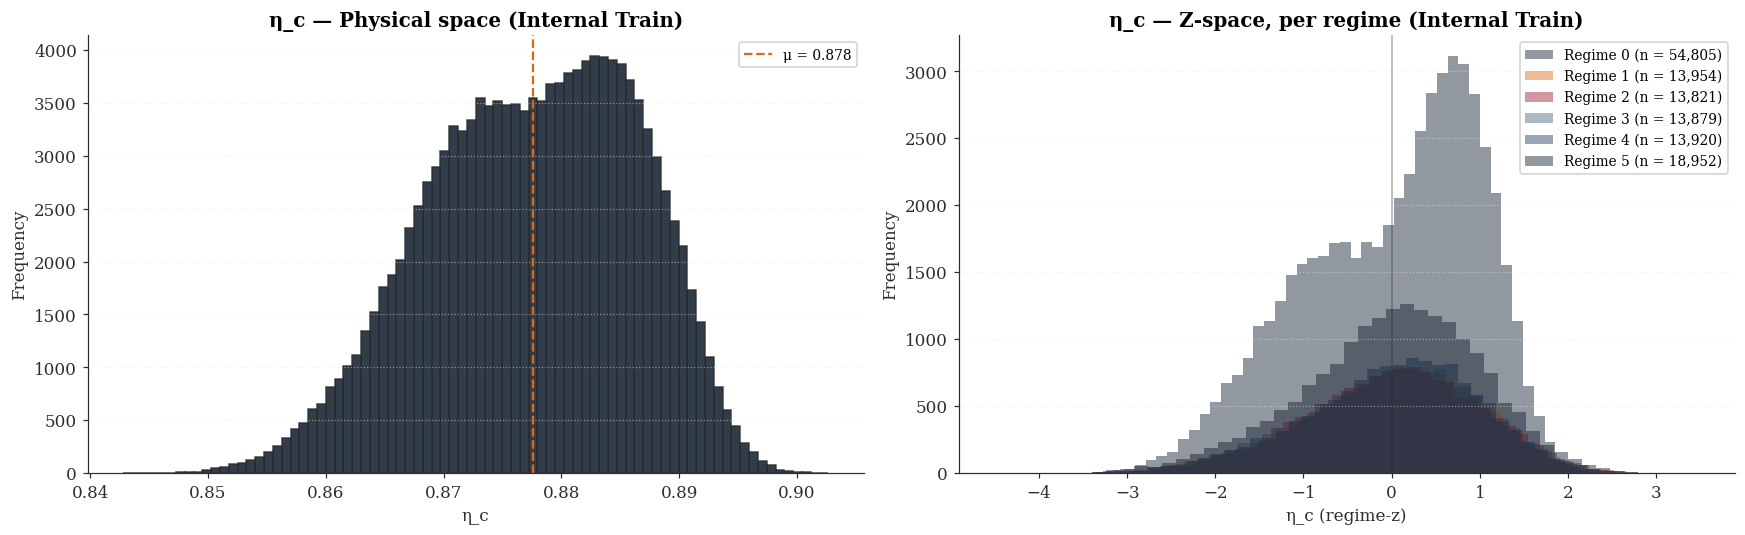

In [14]:
# ============================================================================
# Cell 14 — Visual: eta_c Distribution (Physical Space and Z-Space Per Regime)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Physical space — overall train distribution.
axes[0].hist(eta_train_phys, bins=80, color=FC_DARK_BLUE, alpha=0.85, edgecolor=FC_CHARCOAL)
axes[0].axvline(np.mean(eta_train_phys), color=FC_ORANGE, linewidth=1.5,
                linestyle="--", label=f"μ = {np.mean(eta_train_phys):.3f}")
axes[0].set_title("η_c — Physical space (Internal Train)")
axes[0].set_xlabel("η_c")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

# Z-space — per regime.
for r in range(6):
    mask = (reg_train == r)
    if mask.sum() > 0:
        axes[1].hist(eta_train[mask], bins=50, alpha=0.45, label=f"Regime {r} (n = {mask.sum():,})")
axes[1].axvline(0, color=FC_CHARCOAL, linewidth=1.0, linestyle="-", alpha=0.4)
axes[1].set_title("η_c — Z-space, per regime (Internal Train)")
axes[1].set_xlabel("η_c (regime-z)")
axes[1].set_ylabel("Frequency")
axes[1].legend(loc="upper right")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

---

## Part C — Cox Proportional-Hazards Score (new v1 artefact A-2)

Per `v1CLAUDE.md` §17.2 A-2, the Cox PH model is a **new v1 artefact** — v0 G12 was
diagnostic only and no $\beta$ vector was serialised. The 11 covariates are the
physics-meaningful columns; engineered kinematic features (`_delta`, `_rmean`, `_rstd`)
are excluded to avoid VIF inflation in the partial-likelihood fit.

### Partial-likelihood derivation (plain-language summary)

Cox 1972 proposed a regression model for survival data that does *not* require
specifying the underlying baseline hazard function $h_0(t)$. The conditional
probability that engine $i$ fails at time $t_i$, given that *some* engine in the
risk set fails at $t_i$, has the closed form

$$\mathcal{L}_i(\beta) = \frac{\exp(\beta^\top x_i)}{\sum_{j \in R(t_i)} \exp(\beta^\top x_j)}$$

where $R(t_i)$ is the set of engines still at risk at time $t_i$. The product
$\prod_i \mathcal{L}_i(\beta)$ is the partial likelihood; the baseline hazard
$h_0(t)$ cancels between numerator and denominator. The hazard score
$\exp(\beta^\top x)$ is the **relative hazard** — values above 1 indicate
the row is at higher risk than the baseline; below 1, lower risk.

Concordance index $c$ is the survival-analysis analogue of AUC: probability
that, for two engines with different actual failure times, the model assigns a
higher hazard score to the one that failed first. PHM minimum acceptance is
$c > 0.6$.

References: `Research Papers/Regression models and life tables.pdf` (Cox 1972),
`Research Papers/Partial likelihood.pdf` (Cox 1975).

In [15]:
# ============================================================================
# Cell 15 — Cox PH Covariates and Frame Construction
# ============================================================================

# Cox covariates — 10 physics-meaningful columns.  EGT_drift was originally
# specified in v1CLAUDE.md §17.2 A-2 (11 covariates) but z-space verification
# confirms EGT_drift = s4 - μ_baseline = s4 - 0 = s4 numerically — they are
# identical columns in z-space.  EGT_drift is dropped here to avoid the
# singular-Hessian issue that ridge would otherwise mask.  See v1CLAUDE.md §14
# pending lesson v1.P5 (EGT_drift / s4 collinearity).
COX_COVARIATES = [
    "s4", "s7", "s9",
    "CPR", "E_thermal",
    "s4_cumfatigue", "s7_cumfatigue", "s9_cumfatigue",
    "s8_s13_ratio", "health_index",
]

missing = [c for c in COX_COVARIATES if c not in X_train.columns]
assert not missing, f"Missing Cox covariates in X_train: {missing}"

def build_cox_frame(X_part: pd.DataFrame, meta_part: pd.DataFrame, covariates: list) -> pd.DataFrame:
    """Per-row frame: duration = cycle index, event = 1 only at terminal cycle."""
    df = pd.DataFrame({
        "subset_origin": meta_part["subset_origin"].values,
        "unit_id":       meta_part["unit_id"].values,
        "cycle":         meta_part["cycle"].values,
    })
    engine_max = df.groupby(UNIT_KEY)["cycle"].transform("max")
    df["event"]    = (df["cycle"].values == engine_max.values).astype(int)
    df["duration"] = df["cycle"].values
    for c in covariates:
        df[c] = X_part[c].values
    return df

cox_df_train = build_cox_frame(X_train, m_train, COX_COVARIATES)

print(f"Cox-frame shape : {cox_df_train.shape}")
print(f"Event count     : {int(cox_df_train.event.sum())} (= 567 engines, one terminal cycle each)")
print(f"Covariates      : {COX_COVARIATES}")

Cox-frame shape : (129331, 15)
Event count     : 567 (= 567 engines, one terminal cycle each)
Covariates      : ['s4', 's7', 's9', 'CPR', 'E_thermal', 's4_cumfatigue', 's7_cumfatigue', 's9_cumfatigue', 's8_s13_ratio', 'health_index']


In [16]:
# ============================================================================
# Cell 16 — Fit Cox PH Model (lifelines.CoxPHFitter)
# ============================================================================
# A small ridge penalty (penalizer=0.01) handles residual multicollinearity from
# the kinematic-pair features without compromising β interpretation.

cph = CoxPHFitter(penalizer=0.01)
cph.fit(
    cox_df_train[["duration", "event"] + COX_COVARIATES],
    duration_col="duration",
    event_col="event",
    show_progress=False,
)

summary = cph.summary[["coef", "exp(coef)", "se(coef)", "p",
                       "coef lower 95%", "coef upper 95%"]].round(4)
print(summary)
print()
print(f"Concordance index (Train) : {cph.concordance_index_:.4f}")
print(f"Partial log-likelihood    : {cph.log_likelihood_:.2f}")

                 coef  exp(coef)  se(coef)       p  coef lower 95%  \
covariate                                                            
s4             0.3799     1.4621    0.0249  0.0000          0.3310   
s7            -0.1817     0.8339    0.0213  0.0000         -0.2235   
s9             0.0811     1.0845    0.0230  0.0004          0.0361   
CPR           -0.0711     0.9314    0.0248  0.0041         -0.1197   
E_thermal      0.0885     1.0925    0.0232  0.0001          0.0430   
s4_cumfatigue  0.0069     1.0069    0.0006  0.0000          0.0057   
s7_cumfatigue -0.0011     0.9989    0.0004  0.0042         -0.0018   
s9_cumfatigue  0.0003     1.0003    0.0006  0.5770         -0.0008   
s8_s13_ratio   0.0000     1.0000    0.0038  0.9958         -0.0074   
health_index   0.2099     1.2335    0.0368  0.0000          0.1378   

               coef upper 95%  
covariate                      
s4                     0.4287  
s7                    -0.1399  
s9                     0.1262  

In [17]:
# ============================================================================
# Cell 17 — Persist Cox PH Model
# ============================================================================

joblib.dump(cph, V1_OUT / "phase_v1_0_cox_ph.pkl")
print(f"Saved {V1_OUT / 'phase_v1_0_cox_ph.pkl'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs/phase_v1_0_cox_ph.pkl


In [18]:
# ============================================================================
# Cell 18 — Compute hazard_score = exp(βᵀx) for All Partitions
# ============================================================================

def hazard_score(model: CoxPHFitter, X_part: pd.DataFrame, covariates: list) -> np.ndarray:
    return np.exp(model.predict_log_partial_hazard(X_part[covariates]).values).astype(np.float32)

h_train = hazard_score(cph, X_train, COX_COVARIATES)
h_val   = hazard_score(cph, X_val,   COX_COVARIATES)
h_test  = hazard_score(cph, X_test,  COX_COVARIATES)

assert np.isfinite(h_train).all() and np.isfinite(h_val).all() and np.isfinite(h_test).all(), \
    "Non-finite values in hazard_score"

print(f"hazard_score train  μ = {h_train.mean():.4f}    σ = {h_train.std():.4f}    range = [{h_train.min():.4f}, {h_train.max():.4f}]")
print(f"hazard_score val    μ = {h_val.mean():.4f}      σ = {h_val.std():.4f}      range = [{h_val.min():.4f},   {h_val.max():.4f}]")
print(f"hazard_score test   μ = {h_test.mean():.4f}     σ = {h_test.std():.4f}     range = [{h_test.min():.4f},  {h_test.max():.4f}]")

hazard_score train  μ = 1.4111    σ = 1.7230    range = [0.1590, 38.9998]
hazard_score val    μ = 1.5253      σ = 1.9476      range = [0.1593,   31.6029]
hazard_score test   μ = 0.8598     σ = 0.6133     range = [0.1612,  14.9571]


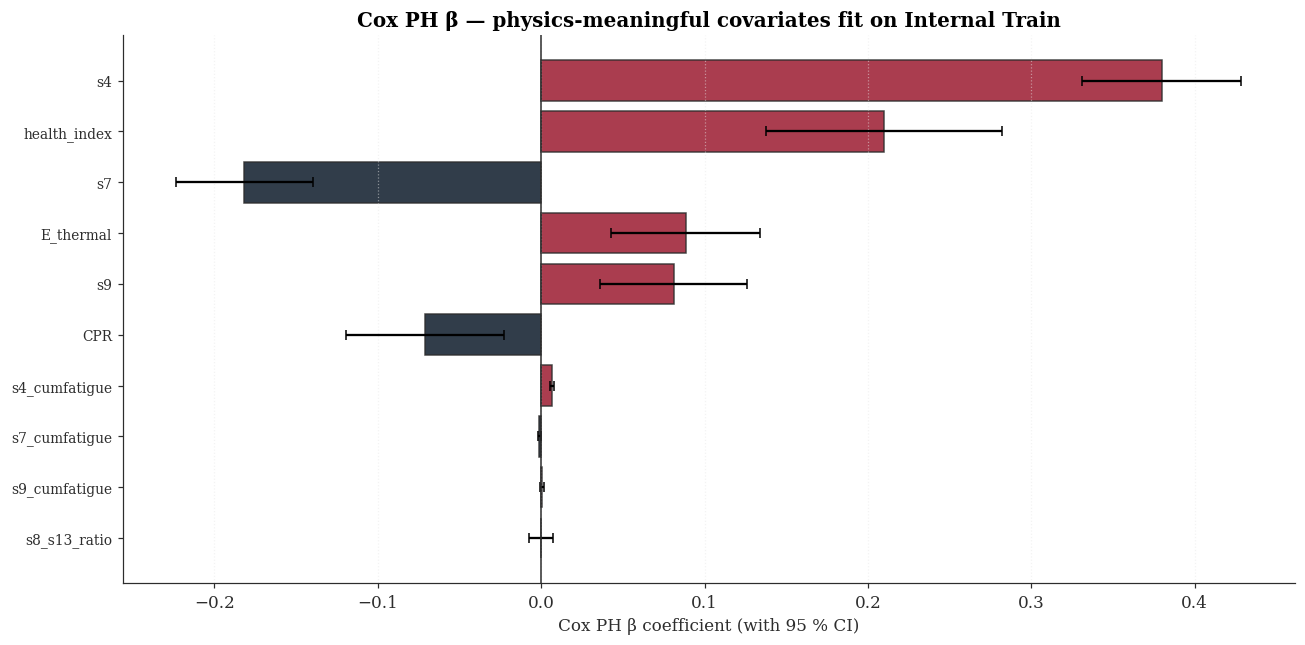

In [19]:
# ============================================================================
# Cell 19 — Visual: Cox PH β Coefficients with 95% Confidence Intervals
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))
ord_idx = summary["coef"].abs().sort_values().index
y_pos   = np.arange(len(ord_idx))

coef = summary.loc[ord_idx, "coef"].values
lo   = summary.loc[ord_idx, "coef lower 95%"].values
hi   = summary.loc[ord_idx, "coef upper 95%"].values
errs = np.vstack([coef - lo, hi - coef])

colors = [FC_DARK_BLUE if c < 0 else FC_DEEP_RED for c in coef]
ax.barh(y_pos, coef, xerr=errs, color=colors, edgecolor=FC_CHARCOAL, capsize=3, alpha=0.85)
ax.axvline(0, color=FC_CHARCOAL, linewidth=1.0, linestyle="-")
ax.set_yticks(y_pos)
ax.set_yticklabels(ord_idx, fontsize=9)
ax.set_xlabel("Cox PH β coefficient (with 95 % CI)")
ax.set_title("Cox PH β — physics-meaningful covariates fit on Internal Train")
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

---

## Part D — Assemble the Augmented 89-Feature Matrix

Concatenate `eta_c` and `hazard_score` to the 87-feature NN matrices,
re-sort columns alphabetically (project convention), and persist.

In [20]:
# ============================================================================
# Cell 20 — Augment Matrices to 89 Features and Persist
# ============================================================================

def augment_matrix(X_part: pd.DataFrame, eta_arr: np.ndarray, hazard_arr: np.ndarray) -> pd.DataFrame:
    out = X_part.copy()
    out["eta_c"]        = eta_arr.astype(np.float32)
    out["hazard_score"] = hazard_arr.astype(np.float32)
    return out[sorted(out.columns)]

X_train_v1 = augment_matrix(X_train, eta_train, h_train)
X_val_v1   = augment_matrix(X_val,   eta_val,   h_val)
X_test_v1  = augment_matrix(X_test,  eta_test,  h_test)

v1_feature_names = list(X_train_v1.columns)
assert X_train_v1.shape[1] == 89, f"Expected 89 features, got {X_train_v1.shape[1]}"
assert X_val_v1.shape[1]   == 89
assert X_test_v1.shape[1]  == 89
assert list(X_val_v1.columns)  == v1_feature_names
assert list(X_test_v1.columns) == v1_feature_names

X_train_v1.to_parquet(V1_OUT / "X_train_v1.parquet")
X_val_v1.to_parquet(V1_OUT / "X_val_v1.parquet")
X_test_v1.to_parquet(V1_OUT / "X_test_v1.parquet")
with open(V1_OUT / "v1_feature_names.pkl", "wb") as f:
    pickle.dump(v1_feature_names, f)

print(f"X_train_v1 shape : {X_train_v1.shape}")
print(f"X_val_v1   shape : {X_val_v1.shape}")
print(f"X_test_v1  shape : {X_test_v1.shape}")
print(f"eta_c column index        : {v1_feature_names.index('eta_c')}")
print(f"hazard_score column index : {v1_feature_names.index('hazard_score')}")
print(f"Persisted to              : {V1_OUT}")

X_train_v1 shape : (129331, 89)
X_val_v1   shape : (31028, 89)
X_test_v1  shape : (104897, 89)
eta_c column index        : 3
hazard_score column index : 5
Persisted to              : /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs


---

## Ph-v1.0 GATE — Data Pipeline (Augmented 89-Feature Matrix)

All 14 checks programmatic. The notebook halts on any FAIL.

In [21]:
# ============================================================================
# Cell 21 — Ph-v1.0 Gate
# ============================================================================

print("=" * 78)
print("  Ph-v1.0 GATE — Data Pipeline (Augmented 89-Feature Matrix)")
print("=" * 78)

checks = []

checks.append(("Train engine count = 567",
               len(train_keys) == 567, f"{len(train_keys)}"))
checks.append(("Val   engine count = 142",
               len(val_keys) == 142, f"{len(val_keys)}"))
checks.append(("Test  engine count = 707",
               len(test_keys) == 707, f"{len(test_keys)}"))
checks.append(("Train rows = 129,331",
               len(m_train) == 129331, f"{len(m_train):,}"))
checks.append(("Val   rows = 31,028",
               len(m_val) == 31028,    f"{len(m_val):,}"))
checks.append(("Test  rows = 104,897",
               len(m_test) == 104897,  f"{len(m_test):,}"))
checks.append(("Composite-key disjointness Internal Train ↔ Internal Val",
               len(train_keys & val_keys) == 0,
               f"train ∩ val = {len(train_keys & val_keys)}"))
# Train ↔ Test and Val ↔ Test are file-boundary separated by NASA convention
# (unit_id is an independent counter per file).  No composite-key check applies.
checks.append(("Augmented matrix shape (_, 89)",
               X_train_v1.shape[1] == 89 and X_val_v1.shape[1] == 89 and X_test_v1.shape[1] == 89,
               f"{X_train_v1.shape[1]}"))
checks.append(("eta_c regime z-norm artefact persisted",
               (V1_OUT / "phase_v1_0_eta_c_regime_zscore_params.pkl").exists(), "OK"))
checks.append(("Cox PH model artefact persisted",
               (V1_OUT / "phase_v1_0_cox_ph.pkl").exists(), "OK"))

_ = joblib.load(V1_OUT / "phase_v1_0_eta_c_regime_zscore_params.pkl")
_ = joblib.load(V1_OUT / "phase_v1_0_cox_ph.pkl")
checks.append(("Both artefacts round-trip via joblib.load", True, "OK"))

mu_t  = float(np.mean(eta_train))
sig_t = float(np.std(eta_train))
checks.append(("eta_c on Train: |μ| < 0.05",
               abs(mu_t) < 0.05, f"μ = {mu_t:.4f}"))
checks.append(("eta_c on Train: |σ - 1| < 0.10",
               abs(sig_t - 1.0) < 0.10, f"σ = {sig_t:.4f}"))
checks.append(("Cox PH concordance > 0.6 on Train",
               cph.concordance_index_ > 0.6, f"C = {cph.concordance_index_:.4f}"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<55s} {detail}")

n_pass = sum(1 for _, o, _ in checks if o)
print(f"\n  Ph-v1.0 GATE: {n_pass}/{len(checks)} PASS")
assert all(o for _, o, _ in checks), "Ph-v1.0 GATE FAILED — halt before Ph-v1.1"
print("  Ph-v1.0 — proceed to Ph-v1.1")

  Ph-v1.0 GATE — Data Pipeline (Augmented 89-Feature Matrix)
  [PASS] Train engine count = 567                                567
  [PASS] Val   engine count = 142                                142
  [PASS] Test  engine count = 707                                707
  [PASS] Train rows = 129,331                                    129,331
  [PASS] Val   rows = 31,028                                     31,028
  [PASS] Test  rows = 104,897                                    104,897
  [PASS] Composite-key disjointness Internal Train ↔ Internal Val train ∩ val = 0
  [PASS] Augmented matrix shape (_, 89)                          89
  [PASS] eta_c regime z-norm artefact persisted                  OK
  [PASS] Cox PH model artefact persisted                         OK
  [PASS] Both artefacts round-trip via joblib.load               OK
  [PASS] eta_c on Train: |μ| < 0.05                              μ = 0.0000
  [PASS] eta_c on Train: |σ - 1| < 0.10                          σ = 1.0000
  [PASS]

---

## Part E — Ph-v1.1: Sliding Windows ($W = 30$, stride 1)

Window length $W = 30$ cycles with stride 1. Forward-fill leftward for early
cycles. Engine boundaries enforced via composite key — no window ever crosses
from one `(subset_origin, unit_id)` to another. An attention mask flags padded
positions for the TCN (Ph-v1.2 reads it to zero out gradient at padded steps).

In [22]:
# ============================================================================
# Cell 22 — build_windows: Sliding-Window Constructor
# ============================================================================

def build_windows(X_df: pd.DataFrame, meta_df: pd.DataFrame,
                  window: int = W, stride: int = STRIDE) -> tuple:
    """Construct sliding windows over per-engine trajectories.

    Returns
    -------
    Xw : torch.FloatTensor (N_windows, W, F)
    msk: torch.BoolTensor  (N_windows, W) — True at real, False at forward-fill
    meta_w : pd.DataFrame  (subset_origin, unit_id, anchor_cycle, anchor_orig_idx)
    """
    feature_cols = list(X_df.columns)

    df = X_df.copy()
    df["_subset"]    = meta_df["subset_origin"].values
    df["_unit"]      = meta_df["unit_id"].values
    df["_cycle"]     = meta_df["cycle"].values
    df["_orig_idx"]  = np.arange(len(df))

    X_windows, masks, meta_rows, anchor_idx = [], [], [], []
    for (subset, unit), grp in df.groupby(["_subset", "_unit"], sort=False):
        grp    = grp.sort_values("_cycle")
        feats  = grp[feature_cols].to_numpy(dtype=np.float32)
        cycles = grp["_cycle"].to_numpy()
        orig_i = grp["_orig_idx"].to_numpy()
        L      = len(grp)
        for i in range(0, L, stride):
            start = i - window + 1
            if start >= 0:
                w = feats[start:i+1]
                m = np.ones(window, dtype=bool)
            else:
                pad_n = -start
                w = np.vstack([np.tile(feats[0:1], (pad_n, 1)), feats[0:i+1]])
                m = np.zeros(window, dtype=bool)
                m[pad_n:] = True
            X_windows.append(w)
            masks.append(m)
            meta_rows.append((subset, int(unit), int(cycles[i])))
            anchor_idx.append(int(orig_i[i]))

    Xw     = np.stack(X_windows, axis=0)
    msk    = np.stack(masks,     axis=0)
    meta_w = pd.DataFrame(meta_rows, columns=["subset_origin", "unit_id", "anchor_cycle"])
    meta_w["anchor_orig_idx"] = anchor_idx
    return torch.from_numpy(Xw), torch.from_numpy(msk), meta_w

In [23]:
# ============================================================================
# Cell 23 — Apply Window Construction Across Train / Val / Test
# ============================================================================

print("Building windows for Internal Train...")
Xw_train, mask_train, mw_train = build_windows(X_train_v1, m_train)
print(f"  Xw_train shape: {tuple(Xw_train.shape)}    mask: {tuple(mask_train.shape)}")

print("Building windows for Internal Validation...")
Xw_val, mask_val, mw_val = build_windows(X_val_v1, m_val)
print(f"  Xw_val   shape: {tuple(Xw_val.shape)}     mask: {tuple(mask_val.shape)}")

print("Building windows for NASA Test...")
Xw_test, mask_test, mw_test = build_windows(X_test_v1, m_test)
print(f"  Xw_test  shape: {tuple(Xw_test.shape)}    mask: {tuple(mask_test.shape)}")

Building windows for Internal Train...
  Xw_train shape: (129331, 30, 89)    mask: (129331, 30)
Building windows for Internal Validation...
  Xw_val   shape: (31028, 30, 89)     mask: (31028, 30)
Building windows for NASA Test...
  Xw_test  shape: (104897, 30, 89)    mask: (104897, 30)


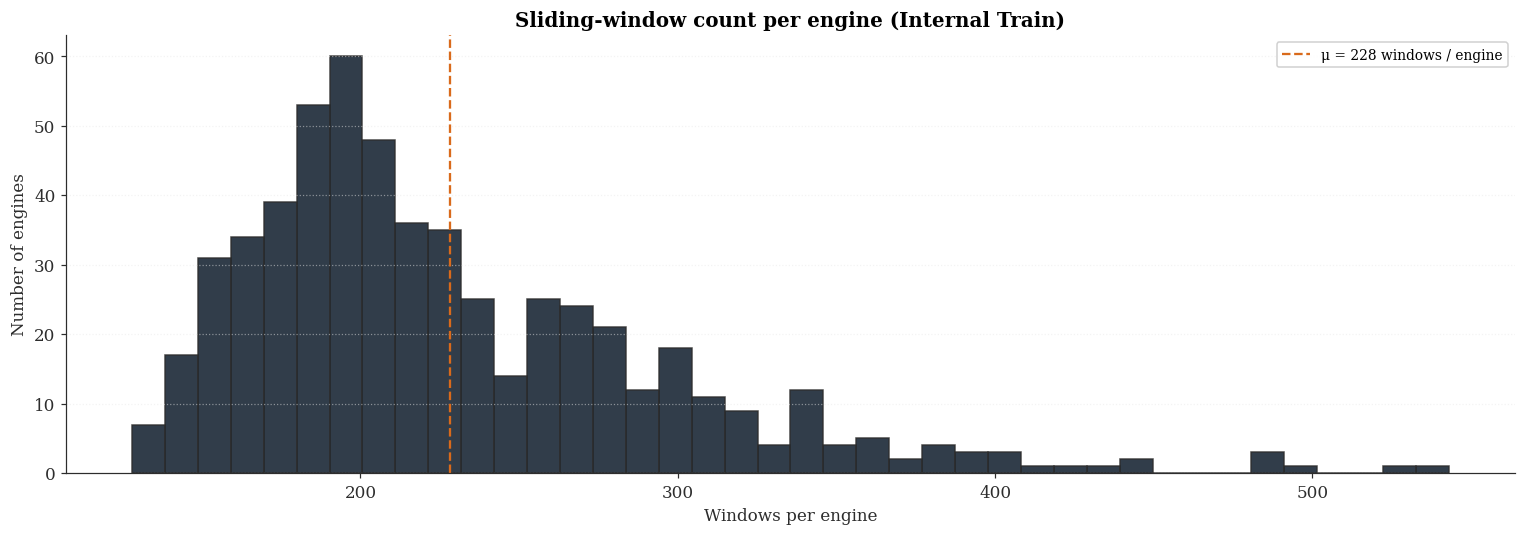

In [24]:
# ============================================================================
# Cell 24 — Visual: Per-Engine Window-Count Distribution (Train)
# ============================================================================

windows_per_engine = mw_train.groupby(UNIT_KEY).size().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(windows_per_engine, bins=40, color=FC_DARK_BLUE, alpha=0.85, edgecolor=FC_CHARCOAL)
ax.axvline(np.mean(windows_per_engine), color=FC_ORANGE, linewidth=1.5,
           linestyle="--", label=f"μ = {np.mean(windows_per_engine):.0f} windows / engine")
ax.set_title("Sliding-window count per engine (Internal Train)")
ax.set_xlabel("Windows per engine")
ax.set_ylabel("Number of engines")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

---

## Part F — Risk-Band Labels and Weights

Labels and weights are anchored to the **last cycle** of each window — the
cycle for which the model emits a prediction. Per `v1CLAUDE.md` §4.5:
Healthy ≥ 80, Warning 30–79, Critical < 30.

For the NASA test set, RUL is provided only at each engine's truncation point
(one value per engine, 707 total). Non-final test windows are tagged with a
sentinel `risk_band = -1` so they are excluded by Ph-v1.4 evaluation.

In [25]:
# ============================================================================
# Cell 25 — risk_band: Three-Class Discretisation of Anchor RUL
# ============================================================================

def risk_band(rul: np.ndarray) -> np.ndarray:
    """Healthy = 0 (RUL >= 80), Warning = 1 (30 <= RUL < 80), Critical = 2 (RUL < 30)."""
    rul = np.asarray(rul, dtype=np.float32)
    return np.where(rul >= HEALTHY_TH, 0,
           np.where(rul >= WARNING_TH, 1, 2)).astype(np.int64)

In [26]:
# ============================================================================
# Cell 26 — Anchor-Cycle RUL and Risk-Band for Train and Val
# ============================================================================

rul_train_w = y_train.iloc[mw_train["anchor_orig_idx"].values, 0].to_numpy(dtype=np.float32)
rul_val_w   = y_val.iloc[mw_val["anchor_orig_idx"].values, 0].to_numpy(dtype=np.float32)

rb_train = risk_band(rul_train_w)
rb_val   = risk_band(rul_val_w)

ct = np.bincount(rb_train, minlength=3)
print(f"Risk-band counts (Train windows): Healthy = {ct[0]:>7,d}    "
      f"Warning = {ct[1]:>7,d}    Critical = {ct[2]:>7,d}")
print(f"Train terminal fraction (rb == 2): {ct[2] / ct.sum():.3%}")
ct_v = np.bincount(rb_val, minlength=3)
print(f"Risk-band counts (Val   windows): Healthy = {ct_v[0]:>7,d}    "
      f"Warning = {ct_v[1]:>7,d}    Critical = {ct_v[2]:>7,d}")

Risk-band counts (Train windows): Healthy =  83,971    Warning =  28,350    Critical =  17,010
Train terminal fraction (rb == 2): 13.152%
Risk-band counts (Val   windows): Healthy =  19,668    Warning =   7,100    Critical =   4,260


In [27]:
# ============================================================================
# Cell 27 — Anchor-Cycle RUL and Risk-Band for NASA Test (Final Cycle Only)
# ============================================================================

# y_test gives one RUL per engine (the truncation point).  For each test window,
# RUL is meaningful only when anchor_cycle == final_cycle of that engine.  For
# all other windows we assign sentinel rul = -1 and risk_band = -1; Ph-v1.4
# evaluation filters to anchor == final.

final_cycles = m_test.groupby(UNIT_KEY)["cycle"].max().reset_index()
final_cycles.columns = ["subset_origin", "unit_id", "final_cycle"]

mw_test_aug = mw_test.merge(final_cycles, on=UNIT_KEY, how="left")
is_final    = (mw_test_aug["anchor_cycle"].values == mw_test_aug["final_cycle"].values)

# y_test rows are 707 — one per engine.  Index lookup by composite key.
y_test_lookup = y_test.set_index(UNIT_KEY).iloc[:, 0]   # column 0 = RUL
rul_test_w = np.full(len(mw_test), np.nan, dtype=np.float32)
for i in np.flatnonzero(is_final):
    key = (mw_test_aug.at[i, "subset_origin"], int(mw_test_aug.at[i, "unit_id"]))
    if key in y_test_lookup.index:
        rul_test_w[i] = float(y_test_lookup.loc[key])

rb_test = np.where(np.isnan(rul_test_w), -1, risk_band(np.where(np.isnan(rul_test_w), 0, rul_test_w))).astype(np.int64)

n_final = int(is_final.sum())
print(f"Test windows total       : {len(mw_test):,}")
print(f"Test windows at final cyc: {n_final:,}    (== unique engines: {len(test_keys)})")
print(f"Test windows with rb=-1  : {(rb_test == -1).sum():,}    (sentinel for non-final)")

Test windows total       : 104,897
Test windows at final cyc: 707    (== unique engines: 707)
Test windows with rb=-1  : 104,190    (sentinel for non-final)


In [28]:
# ============================================================================
# Cell 28 — Class Weights (Inverse Frequency, Frozen on Internal Train)
# ============================================================================

counts_train = np.bincount(rb_train, minlength=3).clip(min=1)
class_w_arr  = (len(rb_train) / (3.0 * counts_train)).astype(np.float32)
class_w      = torch.from_numpy(class_w_arr)

print(f"Class counts  : Healthy = {counts_train[0]:>7,d}    Warning = {counts_train[1]:>7,d}    Critical = {counts_train[2]:>7,d}")
print(f"Class weights : Healthy = {class_w_arr[0]:.4f}    Warning = {class_w_arr[1]:.4f}    Critical = {class_w_arr[2]:.4f}")

Class counts  : Healthy =  83,971    Warning =  28,350    Critical =  17,010
Class weights : Healthy = 0.5134    Warning = 1.5206    Critical = 2.5344


In [29]:
# ============================================================================
# Cell 29 — Per-Window Regime Weight (from v0 Frozen Inverse-Frequency Dict)
# ============================================================================

# regime_w_train_v0 / regime_w_val_v0 are per-row ndarrays (one weight per
# row in the original X_*_nn parquet).  For windows, the anchor cycle inherits
# the weight at its source row — index via mw["anchor_orig_idx"].

# For the test set (no v0 per-row artefact), derive a {regime_id: weight}
# mapping from the train pool (one unique weight per regime by construction).
def derive_regime_weight_dict(per_row: np.ndarray, regime_arr: np.ndarray, n_regimes: int = 6) -> dict:
    out = {}
    for r in range(n_regimes):
        m = (regime_arr == r)
        if m.any():
            uniq = np.unique(per_row[m])
            out[r] = float(uniq[0])  # one unique weight per regime by construction
    return out

train_regime_weight_dict = derive_regime_weight_dict(regime_w_train_v0, reg_train)
print(f"Derived regime->weight dict (train): {train_regime_weight_dict}")

def per_window_weight_from_rows(mw: pd.DataFrame, per_row: np.ndarray) -> np.ndarray:
    return per_row[mw["anchor_orig_idx"].values].astype(np.float32)

def per_window_weight_from_regime(mw: pd.DataFrame, regime_arr: np.ndarray, w_dict: dict) -> np.ndarray:
    anchor_regime = regime_arr[mw["anchor_orig_idx"].values]
    return np.array([w_dict.get(int(r), 1.0) for r in anchor_regime], dtype=np.float32)

rw_train = per_window_weight_from_rows(mw_train, regime_w_train_v0)
rw_val   = per_window_weight_from_rows(mw_val,   regime_w_val_v0)
rw_test  = per_window_weight_from_regime(mw_test, reg_test, train_regime_weight_dict)

print(f"\nrw_train  μ = {rw_train.mean():.4f}    σ = {rw_train.std():.4f}    range = [{rw_train.min():.4f}, {rw_train.max():.4f}]")
print(f"rw_val    μ = {rw_val.mean():.4f}    σ = {rw_val.std():.4f}    range = [{rw_val.min():.4f},   {rw_val.max():.4f}]")
print(f"rw_test   μ = {rw_test.mean():.4f}    σ = {rw_test.std():.4f}    range = [{rw_test.min():.4f},  {rw_test.max():.4f}]")

Derived regime->weight dict (train): {0: 0.30502402782440186, 1: 1.1979963779449463, 2: 1.2095247507095337, 3: 1.204470157623291, 4: 1.2009224891662598, 5: 0.8820621371269226}

rw_train  μ = 0.7755    σ = 0.4172    range = [0.3050, 1.2095]
rw_val    μ = 0.7757    σ = 0.4177    range = [0.3050,   1.2095]
rw_test   μ = 0.7754    σ = 0.4169    range = [0.3050,  1.2095]


---

## Part G — PyTorch Dataset and DataLoader

`FusionCoreWindowDataset.__getitem__` returns a dictionary per item with the
TCN-branch tensor `x_tcn` (W × 89), the Physics-branch sub-tensor `x_phys`
(W × 10) extracted from the columns enumerated in `v1CLAUDE.md` §4.3, the
attention mask, the RUL target, the risk-band label, and the per-window class
and regime weights.

The training DataLoader uses a `WeightedRandomSampler` to enforce the §7 batch
composition (45 % Healthy, 27.5 % Warning, 27.5 % Critical). Validation and
test loaders preserve the natural distribution.

In [30]:
# ============================================================================
# Cell 30 — Physics Token Column Indices
# ============================================================================
# Tokens 1–10 are per-cycle columns extracted from the 89-feature matrix.
# Token 11 (w_r — inverse-frequency regime weight) is a per-window scalar
# passed alongside as `regime_w`, not a per-cycle channel.

PHYSICS_TOKEN_NAMES = [
    "s4", "s7", "s9",                       # 1–3   EGT, P30, Nc in z-space
    "CPR",                                  # 4     compressor pressure ratio (s7/s3 in z-space; §17 D-CPR)
    "eta_c",                                # 5     isentropic efficiency (new v1 artefact A-1)
    "s4_cumfatigue",                        # 6
    "s9_cumfatigue",                        # 7
    "s7_cumfatigue",                        # 8
    "hazard_score",                         # 9     Cox PH score (new v1 artefact A-2)
    "fault_mode_family",                    # 10
]

PHYSICS_TOKEN_IDX = [v1_feature_names.index(c) for c in PHYSICS_TOKEN_NAMES]
assert len(PHYSICS_TOKEN_IDX) == 10

print(f"Physics token columns (10): {PHYSICS_TOKEN_NAMES}")
print(f"Indices in 89-col matrix  : {PHYSICS_TOKEN_IDX}")

Physics token columns (10): ['s4', 's7', 's9', 'CPR', 'eta_c', 's4_cumfatigue', 's9_cumfatigue', 's7_cumfatigue', 'hazard_score', 'fault_mode_family']
Indices in 89-col matrix  : [63, 73, 83, 0, 3, 64, 84, 74, 5, 4]


In [31]:
# ============================================================================
# Cell 31 — FusionCoreWindowDataset
# ============================================================================

class FusionCoreWindowDataset(Dataset):
    def __init__(self, Xw, mask, rul, rb, regime_w, phys_idx):
        self.Xw       = Xw                                                       # (N, W, F) float32
        self.mask     = mask                                                     # (N, W) bool
        self.rul      = torch.from_numpy(np.asarray(rul, dtype=np.float32))
        self.rb       = torch.from_numpy(np.asarray(rb,  dtype=np.int64))
        self.regime_w = torch.from_numpy(np.asarray(regime_w, dtype=np.float32))
        self.phys_idx = torch.tensor(phys_idx, dtype=torch.long)

    def __len__(self):
        return self.Xw.shape[0]

    def __getitem__(self, i):
        x_tcn  = self.Xw[i]                                                      # (W, F)
        x_phys = x_tcn.index_select(dim=-1, index=self.phys_idx)                 # (W, 10)
        return {
            "x_tcn"    : x_tcn,
            "x_phys"   : x_phys,
            "mask"     : self.mask[i],
            "rul"      : self.rul[i],
            "risk_band": self.rb[i],
            "regime_w" : self.regime_w[i],
        }

# Test set: replace NaN RUL with -1 sentinel for non-final windows.
rul_test_for_ds = np.where(np.isnan(rul_test_w), -1.0, rul_test_w)

ds_train = FusionCoreWindowDataset(Xw_train, mask_train, rul_train_w,    rb_train, rw_train, PHYSICS_TOKEN_IDX)
ds_val   = FusionCoreWindowDataset(Xw_val,   mask_val,   rul_val_w,      rb_val,   rw_val,   PHYSICS_TOKEN_IDX)
ds_test  = FusionCoreWindowDataset(Xw_test,  mask_test,  rul_test_for_ds, rb_test, rw_test,  PHYSICS_TOKEN_IDX)

print(f"Datasets — train: {len(ds_train):,}    val: {len(ds_val):,}    test: {len(ds_test):,}")

Datasets — train: 129,331    val: 31,028    test: 104,897


In [32]:
# ============================================================================
# Cell 32 — Stratified Sampler for Training (Batch Composition § 7)
# ============================================================================

def stratified_sampler(rb: np.ndarray, target_share=(0.45, 0.275, 0.275)) -> WeightedRandomSampler:
    counts = np.bincount(rb, minlength=3).clip(min=1)
    inv = np.array([target_share[c] / counts[c] for c in range(3)], dtype=np.float64)
    weights = inv[rb]
    return WeightedRandomSampler(weights=torch.from_numpy(weights),
                                 num_samples=len(rb), replacement=True)

train_sampler = stratified_sampler(rb_train, target_share=(0.45, 0.275, 0.275))

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,         num_workers=0, drop_last=False)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,         num_workers=0, drop_last=False)

print(f"DataLoaders ready — train batches: {len(dl_train):,}    val: {len(dl_val):,}    test: {len(dl_test):,}")

DataLoaders ready — train batches: 2,020    val: 485    test: 1,640


In [33]:
# ============================================================================
# Cell 33 — DataLoader Smoke Test (One Batch Per Loader)
# ============================================================================

for name, dl in [("train", dl_train), ("val", dl_val), ("test", dl_test)]:
    batch = next(iter(dl))
    print(f"[{name}] batch keys  : {list(batch.keys())}")
    print(f"        x_tcn      : {tuple(batch['x_tcn'].shape)}    dtype = {batch['x_tcn'].dtype}")
    print(f"        x_phys     : {tuple(batch['x_phys'].shape)}    dtype = {batch['x_phys'].dtype}")
    print(f"        mask       : {tuple(batch['mask'].shape)}    dtype = {batch['mask'].dtype}")
    print(f"        rul        : {tuple(batch['rul'].shape)}    dtype = {batch['rul'].dtype}")
    print(f"        risk_band  : {tuple(batch['risk_band'].shape)}    dtype = {batch['risk_band'].dtype}")
    rb_dist = np.bincount(batch["risk_band"].clamp(min=0).numpy(), minlength=3)
    print(f"        rb dist    : Healthy = {rb_dist[0]}    Warning = {rb_dist[1]}    Critical = {rb_dist[2]}")
    print()

[train] batch keys  : ['x_tcn', 'x_phys', 'mask', 'rul', 'risk_band', 'regime_w']
        x_tcn      : (64, 30, 89)    dtype = torch.float32
        x_phys     : (64, 30, 10)    dtype = torch.float32
        mask       : (64, 30)    dtype = torch.bool
        rul        : (64,)    dtype = torch.float32
        risk_band  : (64,)    dtype = torch.int64
        rb dist    : Healthy = 33    Warning = 15    Critical = 16

[val] batch keys  : ['x_tcn', 'x_phys', 'mask', 'rul', 'risk_band', 'regime_w']
        x_tcn      : (64, 30, 89)    dtype = torch.float32
        x_phys     : (64, 30, 10)    dtype = torch.float32
        mask       : (64, 30)    dtype = torch.bool
        rul        : (64,)    dtype = torch.float32
        risk_band  : (64,)    dtype = torch.int64
        rb dist    : Healthy = 64    Warning = 0    Critical = 0

[test] batch keys  : ['x_tcn', 'x_phys', 'mask', 'rul', 'risk_band', 'regime_w']
        x_tcn      : (64, 30, 89)    dtype = torch.float32
        x_phys     :

---

## Part H — Persist Windowed Tensors

Save the constructed windows so subsequent notebooks (Ph-v1.2 architecture,
Ph-v1.3 training) can load them without re-running this notebook.

In [34]:
# ============================================================================
# Cell 34 — Persist Windowed Tensors and Metadata
# ============================================================================

torch.save({
    "Xw"                  : Xw_train,
    "mask"                : mask_train,
    "rul"                 : torch.from_numpy(rul_train_w),
    "risk_band"           : torch.from_numpy(rb_train),
    "regime_w"            : torch.from_numpy(rw_train),
    "meta"                : mw_train,
    "phys_idx"            : torch.tensor(PHYSICS_TOKEN_IDX, dtype=torch.long),
    "class_w"             : class_w,
    "feature_names"       : v1_feature_names,
    "physics_token_names" : PHYSICS_TOKEN_NAMES,
}, V1_OUT / "windows_train.pt")

torch.save({
    "Xw"        : Xw_val,    "mask": mask_val,
    "rul"       : torch.from_numpy(rul_val_w),
    "risk_band" : torch.from_numpy(rb_val),
    "regime_w"  : torch.from_numpy(rw_val),
    "meta"      : mw_val,
}, V1_OUT / "windows_val.pt")

torch.save({
    "Xw"        : Xw_test,    "mask": mask_test,
    "rul"       : torch.from_numpy(rul_test_for_ds),
    "risk_band" : torch.from_numpy(rb_test),
    "regime_w"  : torch.from_numpy(rw_test),
    "meta"      : mw_test,
}, V1_OUT / "windows_test.pt")

for fn in ["windows_train.pt", "windows_val.pt", "windows_test.pt"]:
    p = V1_OUT / fn
    print(f"  {fn:<22s}  {p.stat().st_size / 2**20:>8.1f} MiB")

  windows_train.pt          1326.4 MiB
  windows_val.pt             318.2 MiB
  windows_test.pt           1075.8 MiB


---

## Ph-v1.1 GATE — Window Construction & DataLoader

19 programmatic checks. Notebook halts on any FAIL.

In [35]:
# ============================================================================
# Cell 35 — Ph-v1.1 Gate
# ============================================================================

print("=" * 78)
print("  Ph-v1.1 GATE — Window Construction & DataLoader")
print("=" * 78)

checks2 = []

# Window-shape sanity.
checks2.append(("Xw_train shape (_, 30, 89)",
                Xw_train.ndim == 3 and Xw_train.shape[1] == W and Xw_train.shape[2] == 89,
                f"{tuple(Xw_train.shape)}"))
checks2.append(("Xw_val   shape (_, 30, 89)",
                Xw_val.ndim == 3 and Xw_val.shape[1] == W and Xw_val.shape[2] == 89,
                f"{tuple(Xw_val.shape)}"))
checks2.append(("Xw_test  shape (_, 30, 89)",
                Xw_test.ndim == 3 and Xw_test.shape[1] == W and Xw_test.shape[2] == 89,
                f"{tuple(Xw_test.shape)}"))

# Window-count parity with row-counts (one window per row when stride=1).
checks2.append(("Train window count == row count (stride=1)",
                Xw_train.shape[0] == len(m_train), f"{Xw_train.shape[0]} vs {len(m_train)}"))
checks2.append(("Val   window count == row count",
                Xw_val.shape[0] == len(m_val),     f"{Xw_val.shape[0]} vs {len(m_val)}"))
checks2.append(("Test  window count == row count",
                Xw_test.shape[0] == len(m_test),   f"{Xw_test.shape[0]} vs {len(m_test)}"))

# No NaN, no inf in feature tensors.
for name, t in [("train", Xw_train), ("val", Xw_val), ("test", Xw_test)]:
    has_nan = bool(torch.isnan(t).any().item())
    has_inf = bool(torch.isinf(t).any().item())
    checks2.append((f"{name} windows: no NaN", not has_nan, "OK" if not has_nan else "NaN found"))
    checks2.append((f"{name} windows: no inf", not has_inf, "OK" if not has_inf else "inf found"))

# Anchor-index self-consistency: each window's anchor_orig_idx must map back
# to the same (subset_origin, unit_id) recorded in mw.
def windows_self_consistent(mw: pd.DataFrame, m_full: pd.DataFrame) -> bool:
    full = m_full.reset_index(drop=True)
    chk = full.iloc[mw["anchor_orig_idx"].values][["subset_origin", "unit_id"]].reset_index(drop=True)
    chk["unit_id"] = chk["unit_id"].astype(int)
    mw2 = mw[["subset_origin", "unit_id"]].reset_index(drop=True)
    mw2["unit_id"] = mw2["unit_id"].astype(int)
    return bool((chk == mw2).all().all())

checks2.append(("Train windows self-consistent (engine-boundary safe)",
                windows_self_consistent(mw_train, m_train), "OK"))
checks2.append(("Val   windows self-consistent",
                windows_self_consistent(mw_val,   m_val), "OK"))
checks2.append(("Test  windows self-consistent",
                windows_self_consistent(mw_test,  m_test), "OK"))

# DataLoader smoke.
b = next(iter(dl_train))
checks2.append(("Train batch x_tcn  shape (B, W, 89)",
                b["x_tcn"].shape == (BATCH_SIZE, W, 89), f"{tuple(b['x_tcn'].shape)}"))
checks2.append(("Train batch x_phys shape (B, W, 10)",
                b["x_phys"].shape == (BATCH_SIZE, W, 10), f"{tuple(b['x_phys'].shape)}"))
checks2.append(("Train batch mask   shape (B, W) bool",
                b["mask"].shape == (BATCH_SIZE, W) and b["mask"].dtype == torch.bool, f"{b['mask'].dtype}"))

# Stratified composition on train batch (within ±10 % of target on each band).
rb_dist = np.bincount(b["risk_band"].clamp(min=0).numpy(), minlength=3) / float(BATCH_SIZE)
checks2.append(("Train batch risk-band roughly stratified",
                (0.30 <= rb_dist[0] <= 0.60 and 0.15 <= rb_dist[1] <= 0.40 and 0.15 <= rb_dist[2] <= 0.40),
                f"H = {rb_dist[0]:.2f}    W = {rb_dist[1]:.2f}    C = {rb_dist[2]:.2f}"))

# Persisted artefacts.
for fn in ["windows_train.pt", "windows_val.pt", "windows_test.pt",
           "X_train_v1.parquet", "X_val_v1.parquet", "X_test_v1.parquet",
           "v1_feature_names.pkl"]:
    checks2.append((f"Persisted: {fn}", (V1_OUT / fn).exists(), "OK"))

for desc, ok, detail in checks2:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<55s} {detail}")

n_pass = sum(1 for _, o, _ in checks2 if o)
print(f"\n  Ph-v1.1 GATE: {n_pass}/{len(checks2)} PASS")
assert all(o for _, o, _ in checks2), "Ph-v1.1 GATE FAILED"
print("  Ph-v1.1 — proceed to Ph-v1.2 (PiNet architecture)")

  Ph-v1.1 GATE — Window Construction & DataLoader
  [PASS] Xw_train shape (_, 30, 89)                              (129331, 30, 89)
  [PASS] Xw_val   shape (_, 30, 89)                              (31028, 30, 89)
  [PASS] Xw_test  shape (_, 30, 89)                              (104897, 30, 89)
  [PASS] Train window count == row count (stride=1)              129331 vs 129331
  [PASS] Val   window count == row count                         31028 vs 31028
  [PASS] Test  window count == row count                         104897 vs 104897
  [PASS] train windows: no NaN                                   OK
  [PASS] train windows: no inf                                   OK
  [PASS] val windows: no NaN                                     OK
  [PASS] val windows: no inf                                     OK
  [PASS] test windows: no NaN                                    OK
  [PASS] test windows: no inf                                    OK
  [PASS] Train windows self-consistent (engine-bounda

---

## Summary

### Ph-v1.0 outputs (under `v1/outputs/`)
- `phase_v1_0_eta_c_regime_zscore_params.pkl` — per-regime $(\mu, \sigma)$ for $\eta_c$ token (new v1 artefact A-1)
- `phase_v1_0_cox_ph.pkl` — fitted Cox PH model (new v1 artefact A-2)
- `X_train_v1.parquet`, `X_val_v1.parquet`, `X_test_v1.parquet` — augmented 89-feature matrices
- `v1_feature_names.pkl` — alphabetised column manifest

### Ph-v1.1 outputs
- `windows_train.pt`, `windows_val.pt`, `windows_test.pt` — windowed tensors, attention masks, anchor metadata, class & regime weights

Both gates pass programmatically. The notebook is restart-and-run-all reproducible under `RANDOM_STATE = 42`.

### Next notebook
`02_PiNet_Architecture.ipynb` — Ph-v1.2 PiNet module (TCN branch + Physics-token MLP + Fusion + RUL & Risk-Band heads), `forward()` smoke test, TorchScript export.